<Axes: xlabel='Current density (A/cm$^2$)', ylabel='Cell voltage (V)'>

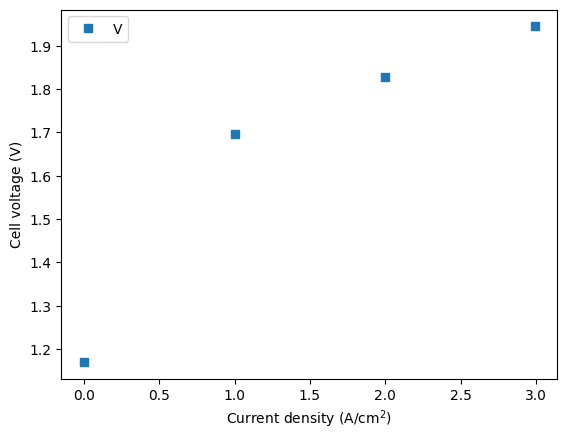

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
import marapendi as mrpd

exp_data = pd.read_csv(f'../data/tricker_et_al_2023/tricker_et_al_2023_fig1d.csv',sep=';',decimal=',')
exp_data_full = pd.read_csv(f'../data/tricker_et_al_2023/tricker_et_al_2023_figS4_IrO2.csv',sep=';',decimal=',')
exp_data.plot(x='i', y='V', marker='s', linewidth=0, 
              ylabel='Cell voltage (V)', xlabel='Current density (A/cm$^2$)')



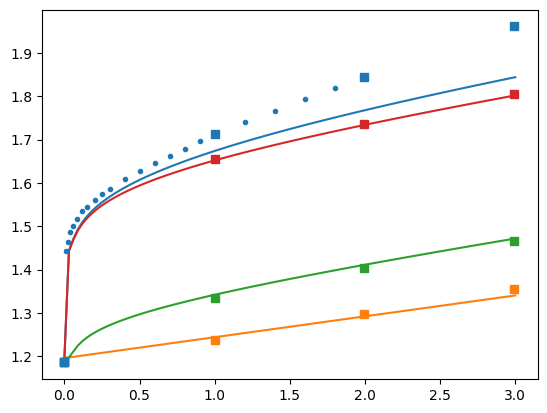

In [11]:
ec = mrpd.ElectrolyzerCell(
    cell_area=5e-4, 
    cell_number=1.,
    electrical_resistance=28e-7,
    ca=mrpd.ElectrolyzerCellSide(
        cl=mrpd.PtCCatalystLayer(
            thickness=12e-6,
            ionomer_to_carbon_ratio=0.5,
            carbon_agglomerate_radius=25e-9,
            platinum_loading=0.3e-2, 
            catalyst_platinum_weight_percent=0.468,
            ecsa=70e3,
            ionomer=mrpd.PAPIonomer(),
            reaction=mrpd.ElectrochemicalReaction(reference_exchange_current_density=40e1/70e3/0.3e-2,
                                                  activation_energy=50e6, 
                                                  reaction_order=0, 
                                                  reference_activity=1., 
                                                  reference_temperature=353.15,charge_transfer_coeff=1)
        ),
        gdl=mrpd.PorousLayer( #AvCarb MGL370 compressed at 20%
            thickness=370e-6 * 0.8, 
            porosity=0.78 * 0.8, 
        )
    ),
    an = mrpd.ElectrolyzerCellSide(
        cl=mrpd.PorousTransferLayer( #Currento 10FP3 SS mesh
            thickness=260e-6, 
            porosity=0.71, 
            ionomer_to_catalyst_ratio=0.2,
            fiber_diameter=20e-6,
            catalyst_density=11700., # IrO2
            catalyst_loading=0.8e-2, # kg/m2
            ecsa=1/(0.8e-2),
            reaction=mrpd.ElectrochemicalReaction(reference_exchange_current_density=.5e-3, #A/m2IrO2
                                                  activation_energy=50e6, 
                                                  reaction_order=0, 
                                                  reference_activity=1., 
                                                  number_of_electrons=2., 
                                                  reference_temperature=353.15,charge_transfer_coeff=1.65),
            ionomer=mrpd.PAPIonomer(),
        ),
        has_mpl=False, 
        has_gdl=False, 
    ),
    membrane=mrpd.PAP85(dry_thickness=30e-6)
    
)

cathode_conditions = mrpd.OperatingConditions(
        inlet_temperature = 353.15,
        inlet_liquid_flow_rate=200e-6/60., # 200 mL/min
        inlet_liquid=mrpd.KOH_1M,
        dry_h2_mole_fraction=1, 
        dry_o2_mole_fraction=0,
        outlet_pressure=1.0e5, 
    )
anode_conditions = mrpd.OperatingConditions(
        inlet_temperature = 353.15,
        inlet_liquid_flow_rate=200e-6/60., # 200 mL/min
        inlet_liquid=mrpd.KOH_1M,
        dry_h2_mole_fraction=0, 
        dry_o2_mole_fraction=1,
        outlet_pressure=1.0e5, 
    )

ec.set_conditions(stack_temperature=353.15, current_density=1e4*np.linspace(0,3,100), cathode_conditions=cathode_conditions, anode_conditions=anode_conditions)
ec.ca.cl.ionomer_water_content=12
ec.an.cl.ionomer_water_content=12
eta_act_ca = ec.ca.cl.activation_overpotential(ec.current_density, 1.)
eta_act_an = ec.an.cl.activation_overpotential(ec.current_density, 1.)
plt.plot(np.linspace(0,3,100), ec.cell_voltage(), 'C0')
plt.plot(np.linspace(0,3,100), ec.reversible_cell_voltage() + ec.high_frequency_resistance() *ec.current_density, 'C1')
plt.plot(np.linspace(0,3,100), ec.reversible_cell_voltage() + ec.high_frequency_resistance() *ec.current_density+ eta_act_ca, 'C2')
plt.plot(np.linspace(0,3,100), ec.reversible_cell_voltage() + ec.high_frequency_resistance() *ec.current_density+ eta_act_ca + eta_act_an, 'C3')

plt.plot(exp_data["i"].values, exp_data["Act_an"].values+0.016, 'C3s', label='$E_{rev}+\eta_{ohm} +\eta_{act,ca}+\eta_{act,an}$')
plt.plot(exp_data["i"].values, exp_data["Act_ca"].values+0.016, 'C2s', label='$E_{rev}+\eta_{ohm} +\eta_{act,ca}$')
plt.plot(exp_data["i"].values, exp_data["Ohmic"].values+0.016, 'C1s', label='$E_{rev}+\eta_{ohm}$')
plt.plot(exp_data["i"].values, exp_data["V"].values+0.016, 'C0s', label='Total')
plt.plot(exp_data_full["Current density (A/cm2)"].values, exp_data_full["Cell voltage (V)"].values, 'C0.', label='Total')

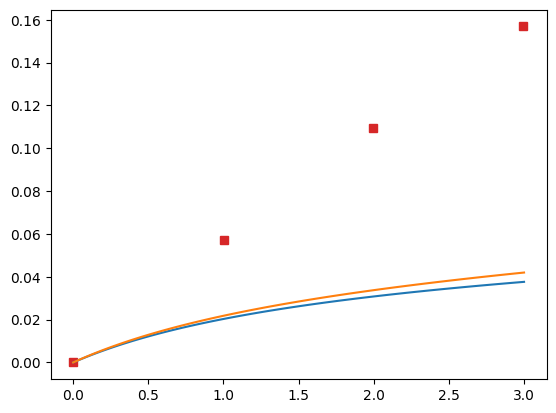

In [6]:
plt.plot(exp_data["i"].values, exp_data["V"].values - exp_data["Act_an"].values, 'C3s', label='$E_{rev}+\eta_{ohm} +\eta_{act,ca}+\eta_{act,an}$')
plt.plot(ec.current_density * 1e-4, ec.an.cl.charge_resistance * ec.current_density)
plt.plot(ec.current_density * 1e-4, (ec.an.cl.charge_resistance + ec.ca.cl.charge_resistance) * ec.current_density)


[]

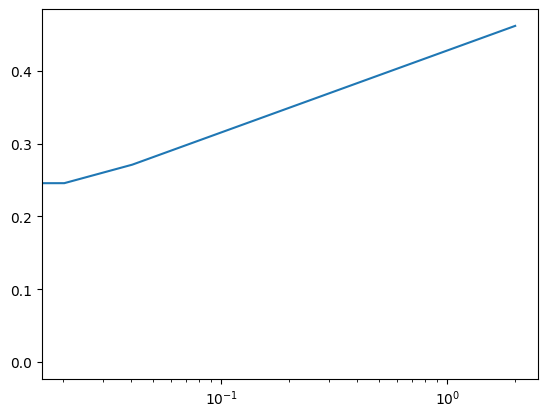

In [ ]:
i = np.linspace(0,2,100)
plt.semilogx(i, ec.activation_overpotential())
plt.plot()